# DS4400 Homework 4

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import roc_curve
from sklearn.naive_bayes import CategoricalNB

### Problem 1

In [41]:
data = np.loadtxt("spambase.data", delimiter=",")
X = data[:, :-1]
y = data[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

tree_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)
tree_entropy.fit(X_train, y_train)

y_train_pred = tree_entropy.predict(X_train)
y_test_pred = tree_entropy.predict(X_test)

y_train_score = tree_entropy.predict_proba(X_train)[:, 1]
y_test_score = tree_entropy.predict_proba(X_test)[:, 1]

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("training error:", 1 - train_acc)
print("training accuracy:", train_acc)
print("training f1:", f1_score(y_train, y_train_pred))
print("training auc:", roc_auc_score(y_train, y_train_score))

print("testing error:", 1 - test_acc)
print("testing accuracy:", test_acc)
print("testing f1:", f1_score(y_test, y_test_pred))
print("testing auc:", roc_auc_score(y_test, y_test_score))

training error: 0.00028985507246381825
training accuracy: 0.9997101449275362
training f1: 0.9996319470003681
training auc: 0.9999998240470653
testing error: 0.0781928757602085
testing accuracy: 0.9218071242397915
testing f1: 0.9015317286652079
testing auc: 0.9193112078827448


The training metrics are almost perfect, with very high accuracy, F1 score, and AUC, which shows that the model fits the training data extremely well. However, the testing metrics are lower, with higher error and reduced performance. This difference between training and testing results suggests that the model is overfitting. It is learning the training data too closely and does not generalize as well to new data.

In [42]:
tree_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
tree_gini.fit(X_train, y_train)

y_train_pred = tree_gini.predict(X_train)
y_test_pred = tree_gini.predict(X_test)

y_train_score = tree_gini.predict_proba(X_train)[:, 1]
y_test_score = tree_gini.predict_proba(X_test)[:, 1]

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("training error:", 1 - train_acc)
print("training accuracy:", train_acc)
print("training f1:", f1_score(y_train, y_train_pred))
print("training auc:", roc_auc_score(y_train, y_train_score))

print("testing error:", 1 - test_acc)
print("testing accuracy:", test_acc)
print("testing f1:", f1_score(y_test, y_test_pred))
print("testing auc:", roc_auc_score(y_test, y_test_score))

training error: 0.00028985507246381825
training accuracy: 0.9997101449275362
training f1: 0.9996319470003681
training auc: 0.9999998240470653
testing error: 0.09209383145091221
testing accuracy: 0.9079061685490878
testing f1: 0.8862660944206009
testing auc: 0.9082174075174283


Compared to the information gain model, both models have almost identical training performance, with near perfect accuracy, F1, and AUC, showing that both fit the training data extremely well. However, on the testing set, the Gini model performs slightly better. It has lower testing error (0.078 vs 0.092), higher accuracy (0.922 vs 0.908), higher F1 score (0.902 vs 0.886), and higher AUC (0.919 vs 0.908). This suggests that while both models overfit, the Gini-based tree generalizes slightly better than the information gain model on unseen data.

recommended depth: 11
lowest testing error: 0.07298001737619464


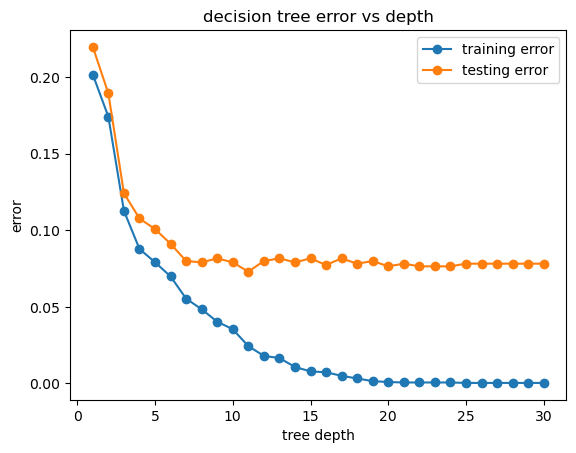

In [43]:
depths = range(1, 31)
train_errors = []
test_errors = []

for d in depths:
    tree = DecisionTreeClassifier(criterion="entropy", max_depth=d, random_state=42)
    tree.fit(X_train, y_train)

    y_train_pred = tree.predict(X_train)
    y_test_pred = tree.predict(X_test)

    train_errors.append(1 - accuracy_score(y_train, y_train_pred))
    test_errors.append(1 - accuracy_score(y_test, y_test_pred))

best_depth = depths[np.argmin(test_errors)]

print("recommended depth:", best_depth)
print("lowest testing error:", min(test_errors))

plt.plot(depths, train_errors, marker="o", label="training error")
plt.plot(depths, test_errors, marker="o", label="testing error")
plt.xlabel("tree depth")
plt.ylabel("error")
plt.title("decision tree error vs depth")
plt.legend()
plt.show()

As the tree depth increases, the training error steadily decreases and eventually becomes almost zero, showing that the model is fitting the training data very closely. The testing error decreases at first, which means the model is improving, but after a certain point it starts to level off and slightly increase, indicating overfitting. The lowest testing error occurs at depth 11, so this is the optimal depth. At this point, the model achieves the best balance between fitting the training data and generalizing well to unseen data.

### Problem 2

In [44]:
n_trees_list = [10, 50, 100, 500]

for T in n_trees_list:
    rf = RandomForestClassifier(n_estimators=T, random_state=42)
    rf.fit(X_train, y_train)

    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)

    y_train_score = rf.predict_proba(X_train)[:, 1]
    y_test_score = rf.predict_proba(X_test)[:, 1]

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    print("T =", T)
    print("training accuracy:", train_acc)
    print("training f1:", f1_score(y_train, y_train_pred))
    print("training auc:", roc_auc_score(y_train, y_train_score))
    print("testing accuracy:", test_acc)
    print("testing f1:", f1_score(y_test, y_test_pred))
    print("testing auc:", roc_auc_score(y_test, y_test_score))
    print()

T = 10
training accuracy: 0.9971014492753624
training f1: 0.996309963099631
training auc: 0.9999713196716438
testing accuracy: 0.9417897480451781
testing f1: 0.9241223103057757
testing auc: 0.9772404072835753

T = 50
training accuracy: 0.9997101449275362
training f1: 0.9996322177271055
training auc: 0.9999998240470653
testing accuracy: 0.947002606429192
testing f1: 0.9310734463276836
testing auc: 0.9851898318153951

T = 100
training accuracy: 0.9997101449275362
training f1: 0.9996322177271055
training auc: 0.9999998240470653
testing accuracy: 0.9513466550825369
testing f1: 0.9370786516853933
testing auc: 0.9859419538740606

T = 500
training accuracy: 0.9997101449275362
training f1: 0.9996322177271055
training auc: 0.9999998240470652
testing accuracy: 0.9513466550825369
testing f1: 0.9367945823927766
testing auc: 0.9863259153451861



As T increases, the training metrics quickly become almost perfect and stay constant, showing that the model fits the training data very well even with a moderate number of trees. The testing metrics improve from T=10 to T=100, with increases in accuracy, F1 score, and AUC, meaning the model is generalizing better as more trees are added. However, after T=100, the improvements become very small and mostly level off, indicating diminishing returns. This shows that increasing the number of trees helps at first, but beyond a certain point, it does not significantly improve performance.

In [46]:
rf_results = []

for T in n_trees_list:
    rf = RandomForestClassifier(n_estimators=T, random_state=42)
    rf.fit(X_train, y_train)

    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)

    y_train_score = rf.predict_proba(X_train)[:, 1]
    y_test_score = rf.predict_proba(X_test)[:, 1]

    rf_results.append({
        "T": T,
        "train_accuracy": accuracy_score(y_train, y_train_pred),
        "train_f1": f1_score(y_train, y_train_pred),
        "train_auc": roc_auc_score(y_train, y_train_score),
        "test_accuracy": accuracy_score(y_test, y_test_pred),
        "test_f1": f1_score(y_test, y_test_pred),
        "test_auc": roc_auc_score(y_test, y_test_score)
    })

for row in rf_results:
    print("T =", row["T"])
    print("train_accuracy:", row["train_accuracy"])
    print("train_f1:", row["train_f1"])
    print("train_auc:", row["train_auc"])
    print("test_accuracy:", row["test_accuracy"])
    print("test_f1:", row["test_f1"])
    print("test_auc:", row["test_auc"])
    print()

T = 10
train_accuracy: 0.9971014492753624
train_f1: 0.996309963099631
train_auc: 0.9999713196716438
test_accuracy: 0.9417897480451781
test_f1: 0.9241223103057757
test_auc: 0.9772404072835753

T = 50
train_accuracy: 0.9997101449275362
train_f1: 0.9996322177271055
train_auc: 0.9999998240470653
test_accuracy: 0.947002606429192
test_f1: 0.9310734463276836
test_auc: 0.9851898318153951

T = 100
train_accuracy: 0.9997101449275362
train_f1: 0.9996322177271055
train_auc: 0.9999998240470653
test_accuracy: 0.9513466550825369
test_f1: 0.9370786516853933
test_auc: 0.9859419538740606

T = 500
train_accuracy: 0.9997101449275362
train_f1: 0.9996322177271055
train_auc: 0.9999998240470652
test_accuracy: 0.9513466550825369
test_f1: 0.9367945823927766
test_auc: 0.9863259153451861



Compared to the single decision tree from Problem 1, the Random Forest shows much better performance on the testing set. While both models have very high training metrics, the decision tree had lower testing performance due to overfitting. In contrast, the Random Forest achieves higher testing accuracy, F1 score, and AUC across all values of T, indicating better generalization. As more trees are added, the Random Forest reduces overfitting by averaging multiple trees, leading to improved test performance compared to a single decision tree.

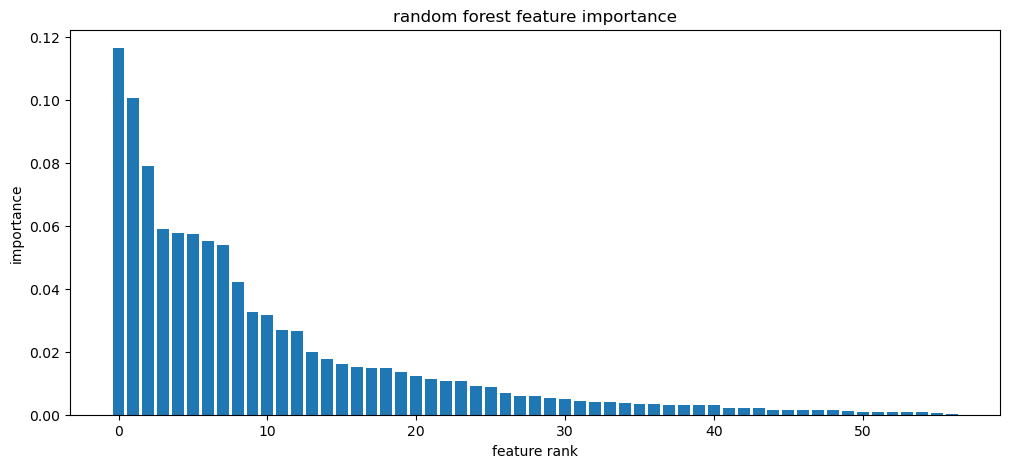

top 10 features:
feature 51 importance: 0.11648213863316677
feature 52 importance: 0.10076725146366312
feature 6 importance: 0.07910979117491364
feature 15 importance: 0.059121630058383515
feature 55 importance: 0.05779630846438539
feature 56 importance: 0.057397510086467214
feature 54 importance: 0.05524359684625987
feature 20 importance: 0.053949455276190876
feature 24 importance: 0.04209155111243154
feature 23 importance: 0.03277757560902329


In [47]:
rf_best = RandomForestClassifier(n_estimators=100, random_state=42)
rf_best.fit(X_train, y_train)

importance = rf_best.feature_importances_
idx = np.argsort(importance)[::-1]

plt.figure(figsize=(12, 5))
plt.bar(range(len(importance)), importance[idx])
plt.xlabel("feature rank")
plt.ylabel("importance")
plt.title("random forest feature importance")
plt.show()

print("top 10 features:")
for i in range(10):
    print("feature", idx[i], "importance:", importance[idx[i]])

### Problem 3

In [22]:
n_learners_list = [10, 50, 100, 500]

for T in n_learners_list:
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        n_estimators=T,
        random_state=42
    )
    ada.fit(X_train, y_train)

    y_train_pred = ada.predict(X_train)
    y_test_pred = ada.predict(X_test)

    y_train_score = ada.predict_proba(X_train)[:, 1]
    y_test_score = ada.predict_proba(X_test)[:, 1]

    print("T =", T)
    print("training accuracy:", accuracy_score(y_train, y_train_pred))
    print("training f1:", f1_score(y_train, y_train_pred))
    print("training auc:", roc_auc_score(y_train, y_train_score))
    print("testing accuracy:", accuracy_score(y_test, y_test_pred))
    print("testing f1:", f1_score(y_test, y_test_pred))
    print("testing auc:", roc_auc_score(y_test, y_test_score))
    print()

T = 10
training accuracy: 0.9057971014492754
training f1: 0.8807339449541285
training auc: 0.9637749857566099
testing accuracy: 0.891398783666377
testing f1: 0.8615725359911407
testing auc: 0.9544887150089433

T = 50
training accuracy: 0.9347826086956522
training f1: 0.9155722326454033
training auc: 0.9814030064726046
testing accuracy: 0.9209383145091226
testing f1: 0.8976377952755905
testing auc: 0.976167527288126

T = 100
training accuracy: 0.9414492753623188
training f1: 0.9247391952309985
training auc: 0.9842641771437841
testing accuracy: 0.9313640312771503
testing f1: 0.911731843575419
testing auc: 0.978939002269007

T = 500
training accuracy: 0.9521739130434783
training f1: 0.9387300408466395
training auc: 0.9902119141954956
testing accuracy: 0.9374456993918332
testing f1: 0.9194630872483222
testing auc: 0.982838660337886



In [27]:
ada_results = []

for T in n_learners_list:
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        n_estimators=T,
        random_state=42
    )
    ada.fit(X_train, y_train)

    y_train_pred = ada.predict(X_train)
    y_test_pred = ada.predict(X_test)

    y_train_score = ada.predict_proba(X_train)[:, 1]
    y_test_score = ada.predict_proba(X_test)[:, 1]

    ada_results.append({
        "T": T,
        "train_accuracy": accuracy_score(y_train, y_train_pred),
        "train_f1": f1_score(y_train, y_train_pred),
        "train_auc": roc_auc_score(y_train, y_train_score),
        "test_accuracy": accuracy_score(y_test, y_test_pred),
        "test_f1": f1_score(y_test, y_test_pred),
        "test_auc": roc_auc_score(y_test, y_test_score)
    })

for i in range(len(n_learners_list)):
    T = n_learners_list[i]

    ada = ada_results[i]
    rf = rf_results[i]

    print("T =", T)
    print("AdaBoost")
    print("training accuracy:", ada["train_accuracy"])
    print("training f1:", ada["train_f1"])
    print("training auc:", ada["train_auc"])
    print("testing accuracy:", ada["test_accuracy"])
    print("testing f1:", ada["test_f1"])
    print("testing auc:", ada["test_auc"])
    print()

    print("Random Forest")
    print("training accuracy:", rf["train_accuracy"])
    print("training f1:", rf["train_f1"])
    print("training auc:", rf["train_auc"])
    print("testing accuracy:", rf["test_accuracy"])
    print("testing f1:", rf["test_f1"])
    print("testing auc:", rf["test_auc"])
    print("\n")

T = 10
AdaBoost
training accuracy: 0.9057971014492754
training f1: 0.8807339449541285
training auc: 0.9637749857566099
testing accuracy: 0.891398783666377
testing f1: 0.8615725359911407
testing auc: 0.9544887150089433

Random Forest
training accuracy: 0.9971014492753624
training f1: 0.996309963099631
training auc: 0.9999713196716438
testing accuracy: 0.9417897480451781
testing f1: 0.9241223103057757
testing auc: 0.9772404072835753


T = 50
AdaBoost
training accuracy: 0.9347826086956522
training f1: 0.9155722326454033
training auc: 0.9814030064726046
testing accuracy: 0.9209383145091226
testing f1: 0.8976377952755905
testing auc: 0.976167527288126

Random Forest
training accuracy: 0.9997101449275362
training f1: 0.9996322177271055
training auc: 0.9999998240470653
testing accuracy: 0.947002606429192
testing f1: 0.9310734463276836
testing auc: 0.9851898318153951


T = 100
AdaBoost
training accuracy: 0.9414492753623188
training f1: 0.9247391952309985
training auc: 0.9842641771437841
testin

Across all values of T, Random Forest consistently achieves much higher training performance than AdaBoost, with near-perfect accuracy, F1, and AUC, while AdaBoost has lower training metrics. This shows that Random Forest fits the training data more strongly. On the testing set, Random Forest also performs better than AdaBoost for every value of T. It has higher accuracy, F1 score, and AUC, indicating better generalization. AdaBoost improves as T increases, with increases in all metrics, but it still does not match Random Forest’s performance.

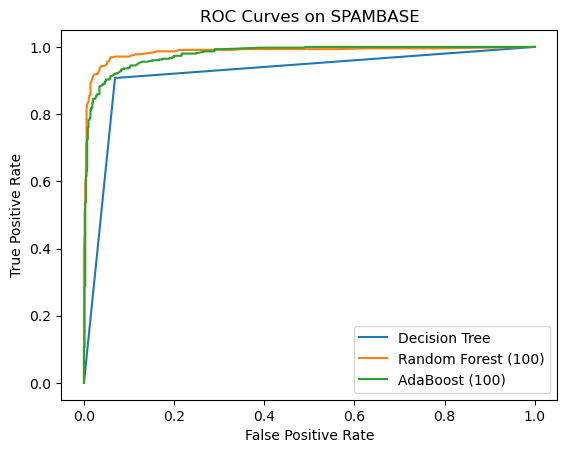

In [25]:
tree_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)
tree_entropy.fit(X_train, y_train)
tree_score = tree_entropy.predict_proba(X_test)[:, 1]

rf_100 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_100.fit(X_train, y_train)
rf_score = rf_100.predict_proba(X_test)[:, 1]

ada_100 = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=100,
    random_state=42
)
ada_100.fit(X_train, y_train)
ada_score = ada_100.predict_proba(X_test)[:, 1]

tree_fpr, tree_tpr, _ = roc_curve(y_test, tree_score)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_score)
ada_fpr, ada_tpr, _ = roc_curve(y_test, ada_score)

plt.plot(tree_fpr, tree_tpr, label="Decision Tree")
plt.plot(rf_fpr, rf_tpr, label="Random Forest (100)")
plt.plot(ada_fpr, ada_tpr, label="AdaBoost (100)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves on SPAMBASE")
plt.legend()
plt.show()

### Problem 4

In [29]:
mushroom = pd.read_csv("agaricus-lepiota.data", header=None)

y = mushroom.iloc[:, 0]
X = mushroom.iloc[:, 1:].copy()

for col in X.columns:
    X[col] = X[col].astype("category")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

classes = sorted(y_train.unique())
feature_values = {col: sorted(X_train[col].unique()) for col in X_train.columns}

priors = {}
cond_probs = {}

for c in classes:
    y_c = y_train[y_train == c]
    priors[c] = len(y_c) / len(y_train)
    cond_probs[c] = {}

    X_c = X_train.loc[y_train == c]

    for col in X_train.columns:
        cond_probs[c][col] = {}
        k = len(feature_values[col])

        for val in feature_values[col]:
            count = (X_c[col] == val).sum()
            cond_probs[c][col][val] = (count + 1) / (len(X_c) + k)

print("prior probabilities")
for c in classes:
    print(c, ":", priors[c])

print()
print("example conditional probabilities for first feature")
first_feature = X_train.columns[0]

for c in classes:
    print("class =", c)
    for val in feature_values[first_feature]:
        print("P(", first_feature, "=", val, "|", c, ") =", cond_probs[c][first_feature][val])
    print()

prior probabilities
e : 0.517971442639094
p : 0.48202855736090594

example conditional probabilities for first feature
class = e
P( 1 = b | e ) = 0.09361163820366857
P( 1 = c | e ) = 0.00031625553447185326
P( 1 = f | e ) = 0.37507906388361795
P( 1 = k | e ) = 0.05471220746363061
P( 1 = s | e ) = 0.007906388361796331
P( 1 = x | e ) = 0.4683744465528147

class = p
P( 1 = b | p ) = 0.01291199456337071
P( 1 = c | p ) = 0.0016989466530750934
P( 1 = f | p ) = 0.39551478083588176
P( 1 = k | p ) = 0.14848793747876315
P( 1 = s | p ) = 0.0003397893306150187
P( 1 = x | p ) = 0.4410465511382943



In [30]:
manual_probs = []
manual_preds = []

for i in range(len(X_test)):
    x = X_test.iloc[i]
    class_scores = {}

    for c in classes:
        score = np.log(priors[c])

        for col in X_test.columns:
            val = x[col]
            if val in cond_probs[c][col]:
                score += np.log(cond_probs[c][col][val])
            else:
                k = len(feature_values[col])
                class_count = (y_train == c).sum()
                score += np.log(1 / (class_count + k))

        class_scores[c] = score

    max_log = max(class_scores.values())
    exp_scores = {c: np.exp(class_scores[c] - max_log) for c in classes}
    total = sum(exp_scores.values())
    probs = {c: exp_scores[c] / total for c in classes}

    manual_probs.append(probs)
    manual_preds.append(max(probs, key=probs.get))

for i in range(5):
    print("test point", i)
    print("P(Edible):", manual_probs[i]["e"])
    print("P(Poisonous):", manual_probs[i]["p"])
    print("predicted class:", manual_preds[i])
    print()

test point 0
P(Edible): 0.9999999639937094
P(Poisonous): 3.6006290577338105e-08
predicted class: e

test point 1
P(Edible): 3.864315924908149e-10
P(Poisonous): 0.9999999996135684
predicted class: p

test point 2
P(Edible): 0.9999970170412559
P(Poisonous): 2.982958744134704e-06
predicted class: e

test point 3
P(Edible): 0.9794623823627127
P(Poisonous): 0.020537617637287352
predicted class: e

test point 4
P(Edible): 7.960976710512225e-13
P(Poisonous): 0.999999999999204
predicted class: p



In [35]:
y_test_num = (y_test == "p").astype(int)
manual_pred_num = pd.Series(manual_preds).map({"e": 0, "p": 1})
manual_prob_p = [p["p"] for p in manual_probs]

print("manual naive bayes")
print("accuracy:", accuracy_score(y_test_num, manual_pred_num))
print("precision:", precision_score(y_test_num, manual_pred_num))
print("recall:", recall_score(y_test_num, manual_pred_num))
print("f1:", f1_score(y_test_num, manual_pred_num))

manual naive bayes
accuracy: 0.9527326440177253
precision: 0.9911012235817576
recall: 0.9101123595505618
f1: 0.9488817891373802


In [36]:
X_train_enc = X_train.copy()
X_test_enc = X_test.copy()

for col in X_train_enc.columns:
    cats = sorted(X_train_enc[col].unique())
    mapping = {cat: i for i, cat in enumerate(cats)}
    X_train_enc[col] = X_train_enc[col].map(mapping)
    X_test_enc[col] = X_test_enc[col].map(mapping)

nb_pkg = CategoricalNB(alpha=1.0)
nb_pkg.fit(X_train_enc, y_train)

pkg_preds = nb_pkg.predict(X_test_enc)
pkg_pred_num = pd.Series(pkg_preds).map({"e": 0, "p": 1})

print("manual naive bayes")
print("accuracy:", accuracy_score(y_test_num, manual_pred_num))
print("precision:", precision_score(y_test_num, manual_pred_num))
print("recall:", recall_score(y_test_num, manual_pred_num))
print("f1:", f1_score(y_test_num, manual_pred_num))
print()

print("package naive bayes")
print("accuracy:", accuracy_score(y_test_num, pkg_pred_num))
print("precision:", precision_score(y_test_num, pkg_pred_num))
print("recall:", recall_score(y_test_num, pkg_pred_num))
print("f1:", f1_score(y_test_num, pkg_pred_num))

manual naive bayes
accuracy: 0.9527326440177253
precision: 0.9911012235817576
recall: 0.9101123595505618
f1: 0.9488817891373802

package naive bayes
accuracy: 0.9527326440177253
precision: 0.9911012235817576
recall: 0.9101123595505618
f1: 0.9488817891373802


The results from the manual Naive Bayes implementation and the package implementation are exactly the same across all metrics, including accuracy, precision, recall, and F1 score. This shows that the manual implementation is correct and matches the behavior of the standard library version. Since both use the same training data and Laplace smoothing, it is expected that they produce identical results.